# Machine Learning Model for Diabetes 🩸🩺🧪 

## Load Data 📂

In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72,35,0.0,33.6,NaN,50,1
1,1,85.0,66,29,0.0,26.6,0.351,31,0
2,8,183.0,64,0,NaN,23.3,0.672,32,1
3,1,89.0,66,23,94.0,28.1,0.167,21,0
4,0,137.0,40,35,NaN,43.1,2.288,33,1


## Exploration 🔎

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 774 entries, 0 to 773
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               774 non-null    int64  
 1   Glucose                   772 non-null    float64
 2   BloodPressure             774 non-null    int64  
 3   SkinThickness             774 non-null    int64  
 4   Insulin                   771 non-null    float64
 5   BMI                       771 non-null    float64
 6   DiabetesPedigreeFunction  771 non-null    float64
 7   Age                       774 non-null    int64  
 8   Outcome                   774 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.6 KB


In [52]:
df.shape

(774, 9)

In [53]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [54]:
df.isnull().sum()

Pregnancies                 0
Glucose                     2
BloodPressure               0
SkinThickness               0
Insulin                     3
BMI                         3
DiabetesPedigreeFunction    3
Age                         0
Outcome                     0
dtype: int64

In [55]:
df.duplicated().sum()

np.int64(6)

## Cleaning & Preprocessing 🧹⚙️

### Fill Null Values

In [56]:
df.fillna(df.mean().round(2), inplace=True)

### Drop Duplication

In [57]:
df.drop_duplicates(inplace=True)

### Descripe Data After Cleaning

In [58]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.886953,31.972062,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.740052,115.156927,0.000,0.00000,34.0000,126.25000,846.00
BMI,768.0,31.988008,7.876465,0.000,27.30000,32.0000,36.52500,67.10
DiabetesPedigreeFunction,768.0,0.471004,0.330799,0.078,0.24375,0.3725,0.62025,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


### Handel Outliers

In [59]:
columns=df.columns
for col in columns:  
    data = df[col] 
    Q1 = data.quantile(0.25) 
    Q3 = data.quantile(0.75) 
    IQR = Q3 - Q1 
    Max = Q3 + 1.5 * IQR 
    Min = Q1 - 1.5 * IQR 

    print(f'Outlier For Column {col} Is :') 
    print(df[(df[col] > Max) | (df[col] < Min)][col]) 
    print('*************************') 

Outlier For Column Pregnancies Is :
88     15
159    17
298    14
461    14
Name: Pregnancies, dtype: int64
*************************
Outlier For Column Glucose Is :
75     0.0
182    0.0
342    0.0
349    0.0
508    0.0
Name: Glucose, dtype: float64
*************************
Outlier For Column BloodPressure Is :
7        0
15       0
18      30
43     110
49       0
60       0
78       0
81       0
84     108
106    122
125     30
172      0
177    110
193      0
222      0
261      0
266      0
269      0
300      0
332      0
336      0
347      0
363      0
368    108
432      0
436      0
441      0
459      0
474      0
490      0
500      0
528      0
539      0
541      0
555    110
595      0
603     24
607      0
610      0
625      0
649      0
697    114
703      0
709      0
712      0
Name: BloodPressure, dtype: int64
*************************
Outlier For Column SkinThickness Is :
585    99
Name: SkinThickness, dtype: int64
*************************
Outlier For Column Ins

#### Boxplots before handel outliers

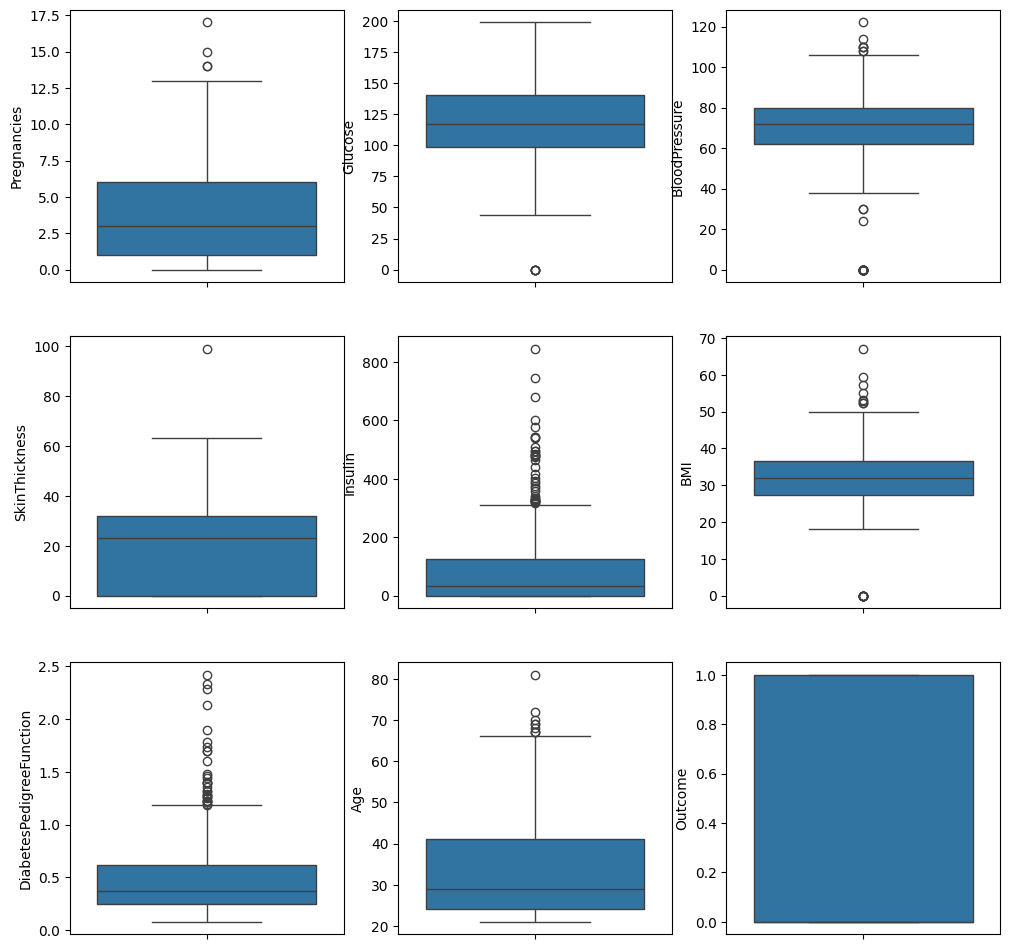

In [60]:
fig , axes = plt.subplots(3,3)
axes= axes.flatten()
fig.set_size_inches(12,12)
for i in range(0,len(columns)):
    sns.boxplot(df[columns[i]],ax=axes[i])

In [61]:
#handelng with the outliers
cols = ['Glucose', 'BloodPressure', 'BMI']
for col in cols:
    df[col]=df[col].replace(0,df[col].median())
df['SkinThickness']=df['SkinThickness'].replace(99,df['SkinThickness'].median())

#### Boxplots After handel outliers

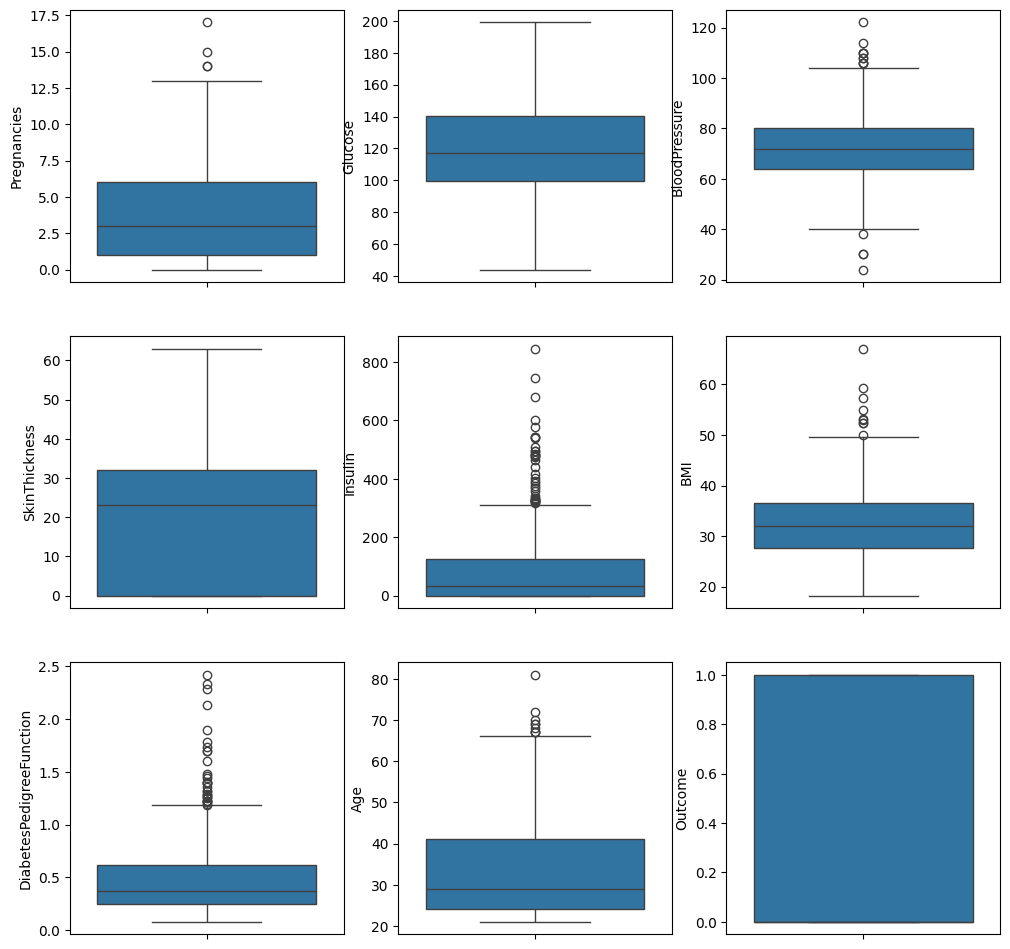

In [62]:
fig , axes = plt.subplots(3,3)
axes= axes.flatten()
fig.set_size_inches(12,12)
for i in range(0,len(columns)):
    sns.boxplot(df[columns[i]],ax=axes[i])

## Visualization 📊📈

### 1) Blood Pressure, Glucose, Insulin By Age

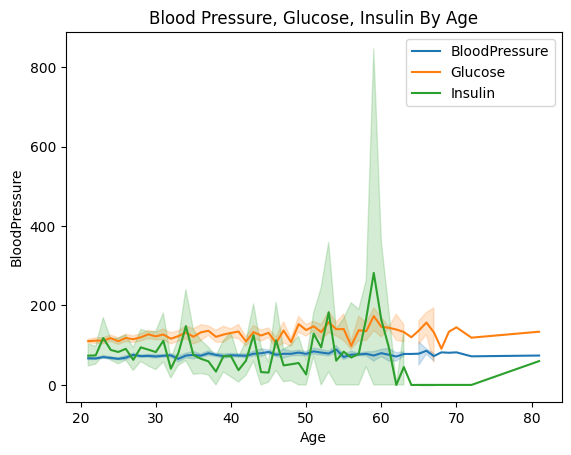

In [63]:
sns.lineplot(x=df['Age'],y=df['BloodPressure'],label ='BloodPressure')
sns.lineplot(x=df['Age'],y=df['Glucose'],label='Glucose')
sns.lineplot(x=df['Age'],y=df['Insulin'],label='Insulin')
plt.title('Blood Pressure, Glucose, Insulin By Age')
plt.show()

### 2) Diabetes Outcome Distribution

C:\Users\ASUS\AppData\Local\Temp\ipykernel_5880\3502517792.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Outcome'], palette='Set2')


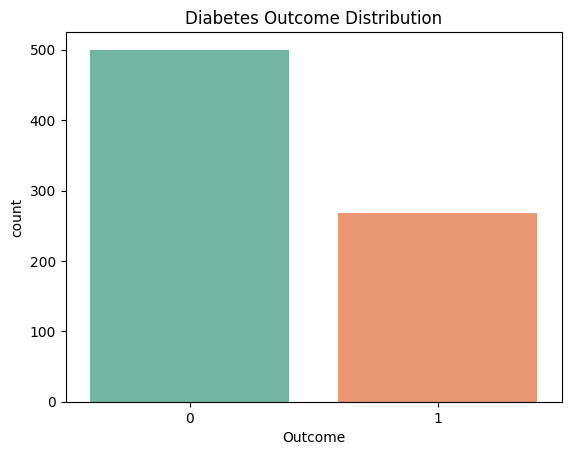

In [82]:
sns.countplot(x=df['Outcome'], palette='Set2')
plt.title('Diabetes Outcome Distribution')
plt.show()

### 3) Glucose Distribution by Outcome

C:\Users\ASUS\AppData\Local\Temp\ipykernel_5880\3790985092.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=df['Outcome'],y=df['Glucose'], palette='muted')


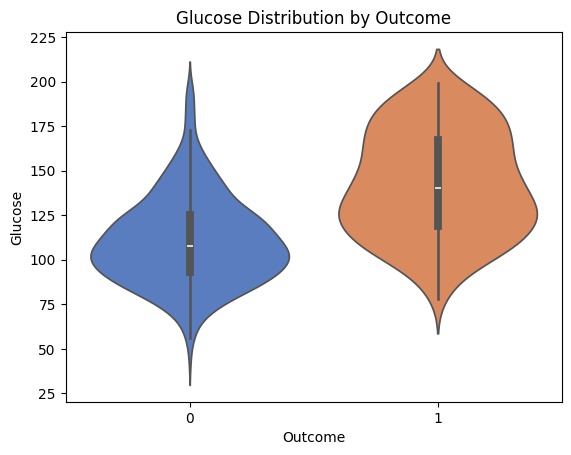

In [84]:
sns.violinplot(x=df['Outcome'],y=df['Glucose'], palette='muted')
plt.title('Glucose Distribution by Outcome')
plt.show()

### 4) Histplot For all dataset

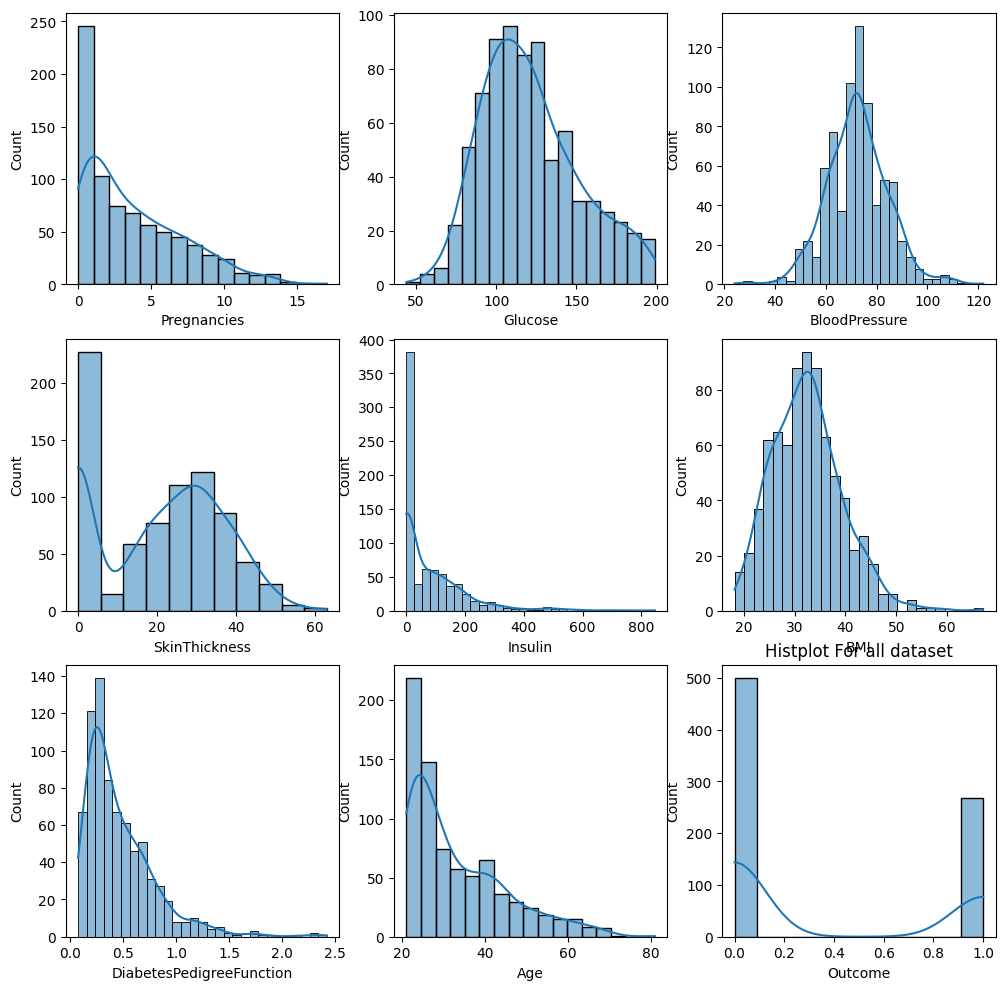

In [91]:
#Histplot
fig , axes = plt.subplots(3,3)
axes= axes.flatten()
fig.set_size_inches(12,12)
for i in range(0,len(columns)):
    sns.histplot(df[columns[i]],kde=True,ax=axes[i])
plt.title('Histplot For all dataset')
plt.show()


### 5) Correlation Heatmap for all dataset

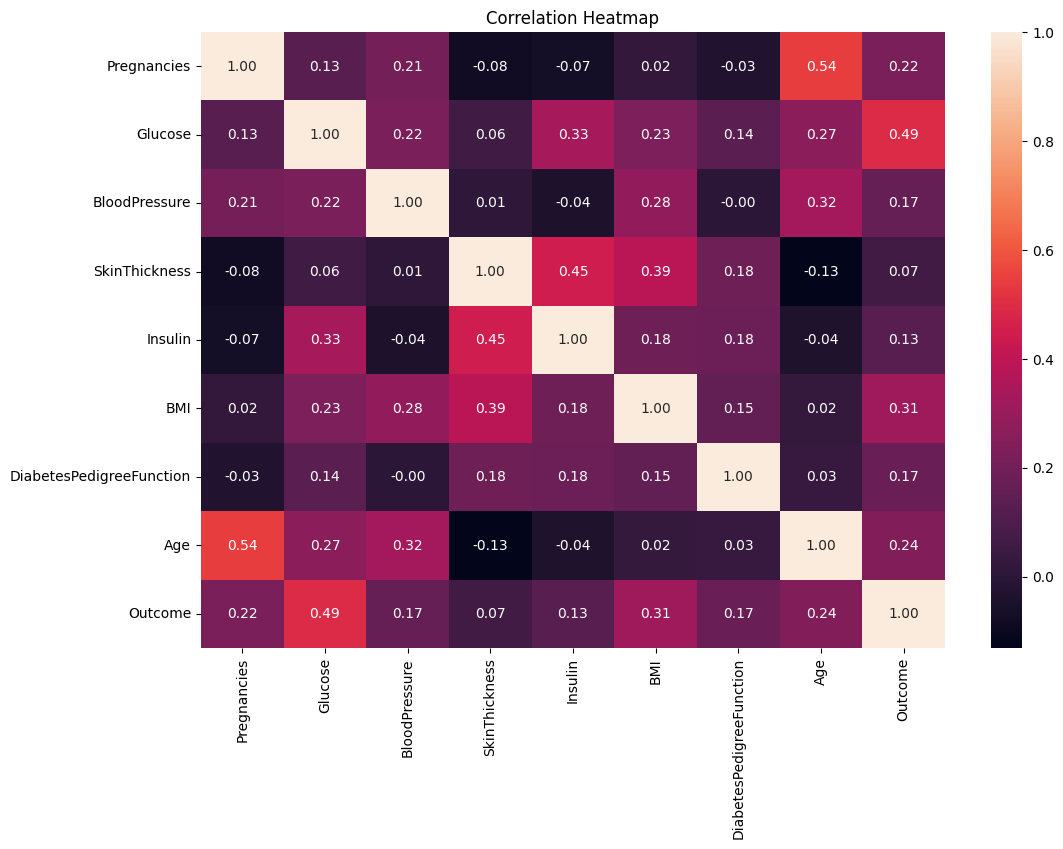

In [ ]:
# Corr
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

### 6) Pairplot for all dataset

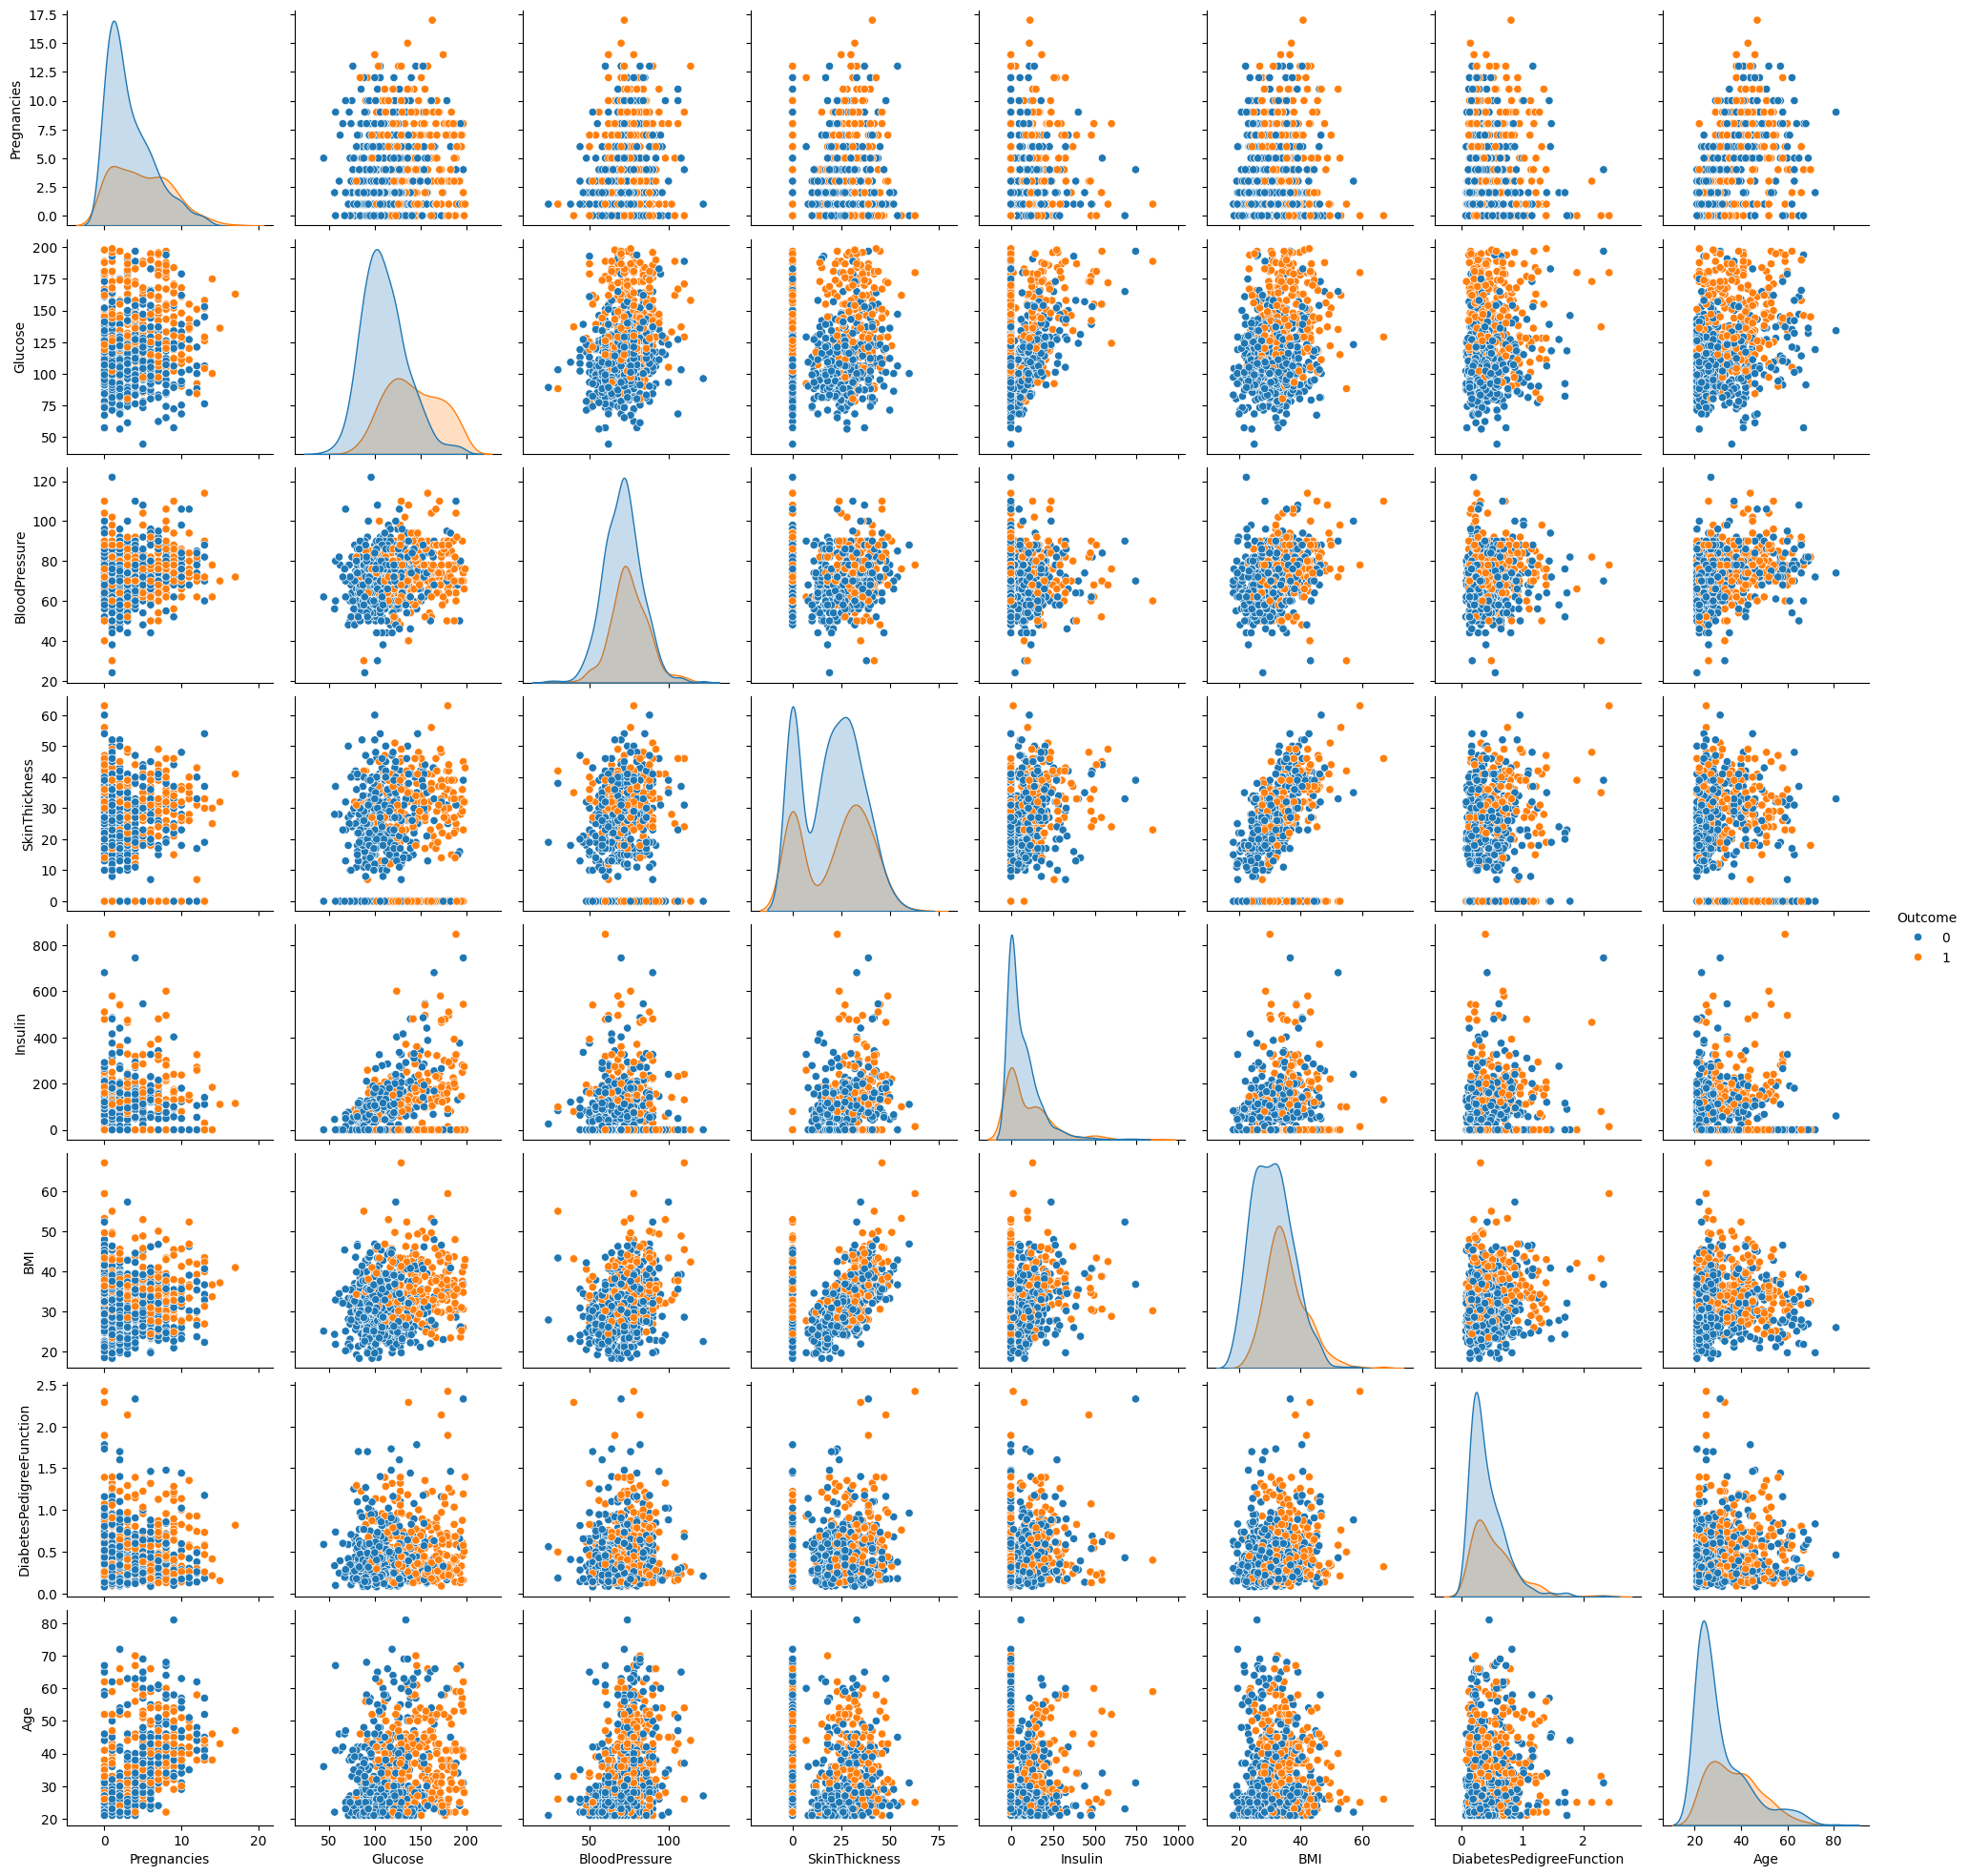

In [93]:
#Pairplot
sns.pairplot(df,hue='Outcome')

In [67]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X = df.drop('Outcome',axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42) # arrays
scasler = StandardScaler()
X_train = scasler.fit_transform(X_train) #Array
X_test = scasler.transform(X_test)

In [68]:
# Data after Scaling
pd.DataFrame(X_train,columns=X.columns)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,-0.526397,-1.256585,-0.018995,-1.322774,-0.699821,-0.050421,-0.488451,-1.035940
1,1.588046,-0.325740,0.808174,0.233505,-0.699821,-0.599484,2.423028,1.487101
2,-0.828460,0.571860,-2.169636,-0.090720,0.015206,-0.527239,0.553489,-0.948939
3,-1.130523,1.303238,-1.838768,-1.322774,-0.699821,-1.509773,-0.637300,2.792122
4,0.681856,0.405638,0.642740,1.076490,2.487647,2.001341,-0.684932,1.139095
...,...,...,...,...,...,...,...,...
609,0.379793,0.571860,-0.680731,0.946800,0.506248,-0.541688,-0.169915,-0.600933
610,-0.828460,-0.857652,4.116852,-1.322774,-0.699821,-1.437528,-0.777218,-0.513932
611,1.890109,-0.691429,1.139042,1.076490,-0.699821,1.914647,1.988390,0.443084
612,-1.130523,0.638349,-0.018995,-1.322774,-0.699821,1.452278,-0.783172,-0.339929


## Models 🤖🧠

In [69]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix,f1_score,classification_report,roc_auc_score,roc_curve


### 1) Logistic Regression

=== Logistic Metrics ===
Accuracy =>  0.78
precision =>  0.78
recall =>  0.78
F1-score: =>  0.78


c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


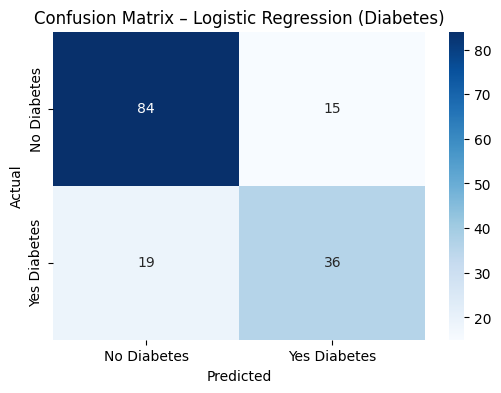

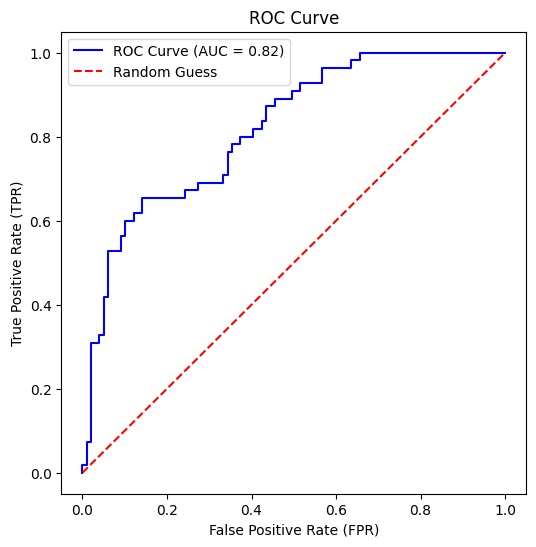

In [70]:
from sklearn.linear_model import LogisticRegression
# probability not important it just till you that outbut is 0 with probability 80% and 1 with probability 20% but it doesn't affect in outbut
log = LogisticRegression(multi_class='multinomial',random_state=42)
log.fit(X_train,y_train)
y_pred = log.predict(X_test)
# print(log.predict_proba(x_test)) # To print Probability of two outbuts
print('=== Logistic Metrics ===')
logistic=accuracy_score(y_test,y_pred)
print('Accuracy => ',f"{accuracy_score(y_test,y_pred):.2f}")
print('precision => ',f"{precision_score(y_test,y_pred,average='weighted'):.2f}")
print('recall => ',f"{recall_score(y_test,y_pred,average='weighted'):.2f}")
print('F1-score: => ',f"{f1_score(y_test,y_pred,average='weighted'):.2f}")
print( '========================' )

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=['No Diabetes', 'Yes Diabetes'], yticklabels=['No Diabetes', 'Yes Diabetes']
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Logistic Regression (Diabetes)")
plt.show()

print( '========================' )
# Get predicted probabilities for the positive class
y_prob = log.predict_proba(X_test)[:, 1]   # probability of class 1

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute AUC
auc = roc_auc_score(y_test, y_prob)

# Plot ROC Curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0,1], [0,1], color='red', linestyle='--', label='Random Guess')  # diagonal line
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend()
plt.show()


### 2) SVC Model

=== SVC Metrics ===
Accuracy =>  0.76
precision =>  0.75
recall =>  0.76
F1-score: =>  0.75


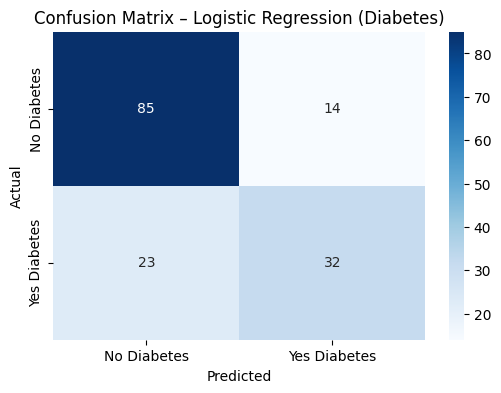

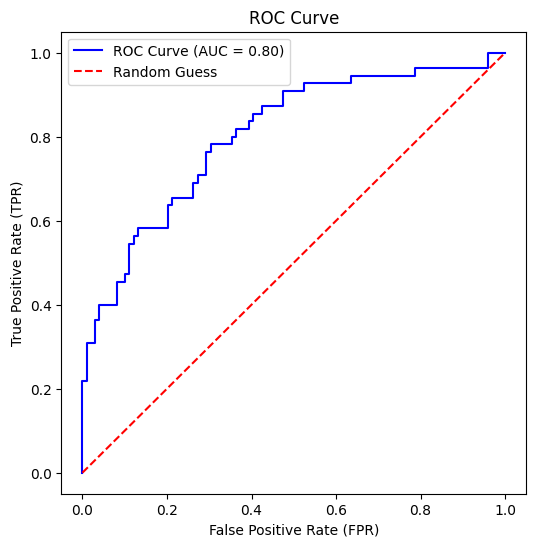

In [71]:
from sklearn.svm import SVC
# probability not important it just till you that outbut is 0 with probability 80% and 1 with probability 20% but it doesn't affect in outbut
svc = SVC(kernel='rbf',probability=True,random_state=42)
svc.fit(X_train,y_train)
y_pred = svc.predict(X_test)
# print(svc.predict_proba(x_test)) # To print Probability of two outbuts
print('=== SVC Metrics ===')
supportvector=accuracy_score(y_test,y_pred)
print('Accuracy => ',f"{accuracy_score(y_test,y_pred):.2f}")
print('precision => ',f"{precision_score(y_test,y_pred,average='weighted'):.2f}")
print('recall => ',f"{recall_score(y_test,y_pred,average='weighted'):.2f}")
print('F1-score: => ',f"{f1_score(y_test,y_pred,average='weighted'):.2f}")
print( '========================' )

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=['No Diabetes', 'Yes Diabetes'], yticklabels=['No Diabetes', 'Yes Diabetes']
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Logistic Regression (Diabetes)")
plt.show()

print( '========================' )
# Get predicted probabilities for the positive class
y_prob = svc.predict_proba(X_test)[:, 1]   # probability of class 1

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute AUC
auc = roc_auc_score(y_test, y_prob)

# Plot ROC Curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0,1], [0,1], color='red', linestyle='--', label='Random Guess')  # diagonal line
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend()
plt.show()

### 3) Knn

=== knn Metrics ===
Accuracy =>  0.73
precision =>  0.72
recall =>  0.73
F1-score: =>  0.72


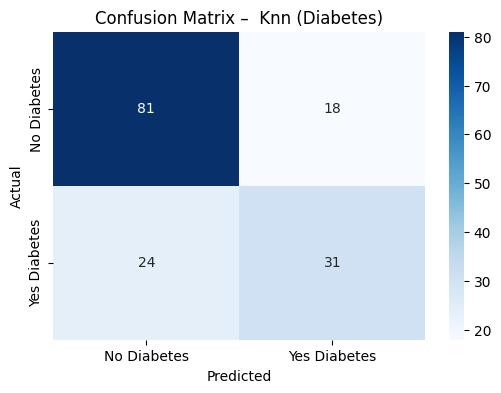

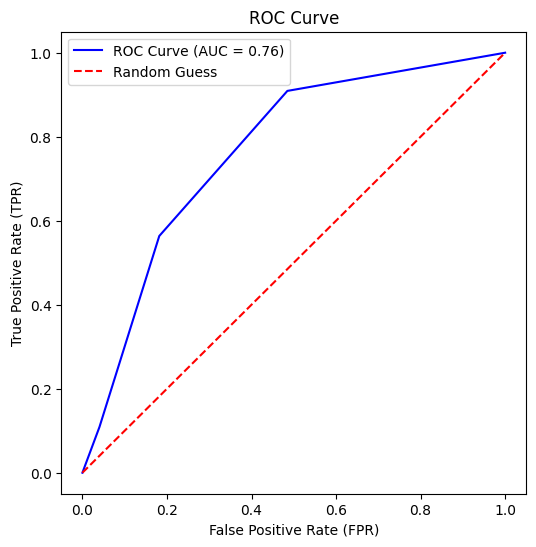

In [72]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train,y_train)
y_pred = knn.predict(X_test)

print('=== knn Metrics ===')
Kneighbor=accuracy_score(y_test,y_pred)
print('Accuracy => ',f"{accuracy_score(y_test,y_pred):.2f}")
print('precision => ',f"{precision_score(y_test,y_pred,average='weighted'):.2f}")
print('recall => ',f"{recall_score(y_test,y_pred,average='weighted'):.2f}")
print('F1-score: => ',f"{f1_score(y_test,y_pred,average='weighted'):.2f}")
print( '========================' )

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=['No Diabetes', 'Yes Diabetes'], yticklabels=['No Diabetes', 'Yes Diabetes']
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix –  Knn (Diabetes)")
plt.show()

print( '========================' )
# Get predicted probabilities for the positive class
y_prob = knn.predict_proba(X_test)[:, 1]   # probability of class 1

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute AUC
auc = roc_auc_score(y_test, y_prob)

# Plot ROC Curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0,1], [0,1], color='red', linestyle='--', label='Random Guess')  # diagonal line
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend()
plt.show()

### 4) Naive Bayes

=== Gaussian Metrics ===
Accuracy =>  0.77
precision =>  0.77
recall =>  0.77
F1-score: =>  0.77


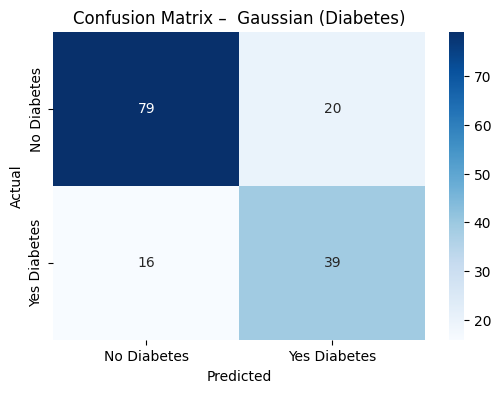

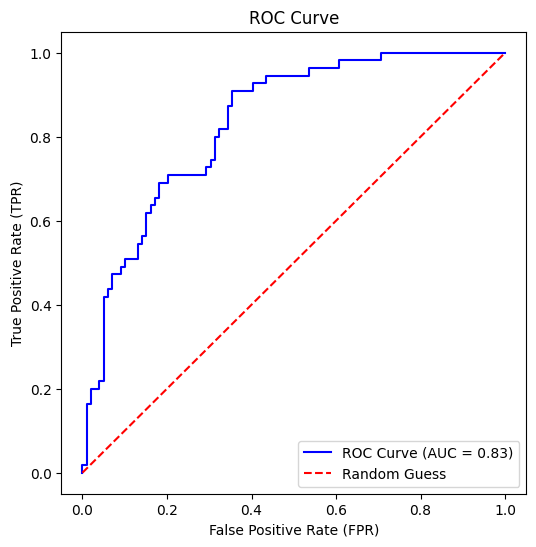

In [73]:
from sklearn.naive_bayes import GaussianNB
Gaussian = GaussianNB()
Gaussian.fit(X_train,y_train)
y_pred = Gaussian.predict(X_test)
print('=== Gaussian Metrics ===')
naive=accuracy_score(y_test,y_pred)
print('Accuracy => ',f"{accuracy_score(y_test,y_pred):.2f}")
print('precision => ',f"{precision_score(y_test,y_pred,average='weighted'):.2f}")
print('recall => ',f"{recall_score(y_test,y_pred,average='weighted'):.2f}")
print('F1-score: => ',f"{f1_score(y_test,y_pred,average='weighted'):.2f}")
print( '========================' )

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=['No Diabetes', 'Yes Diabetes'], yticklabels=['No Diabetes', 'Yes Diabetes']
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix –  Gaussian (Diabetes)")
plt.show()

print( '========================' )
# Get predicted probabilities for the positive class
y_prob = Gaussian.predict_proba(X_test)[:, 1]   # probability of class 1

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute AUC
auc = roc_auc_score(y_test, y_prob)

# Plot ROC Curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0,1], [0,1], color='red', linestyle='--', label='Random Guess')  # diagonal line
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend()
plt.show()


### 5) Neural Network

=== MLP Metrics ===
Accuracy =>  0.80
precision =>  0.80
recall =>  0.80
F1-score: =>  0.79


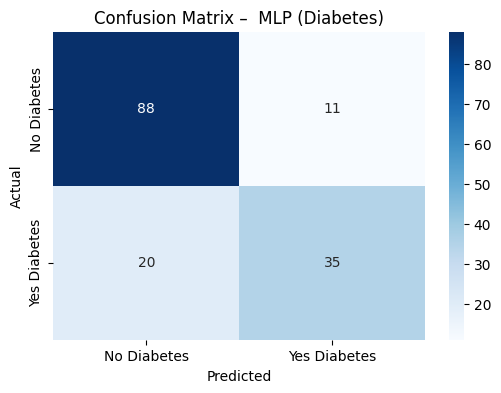

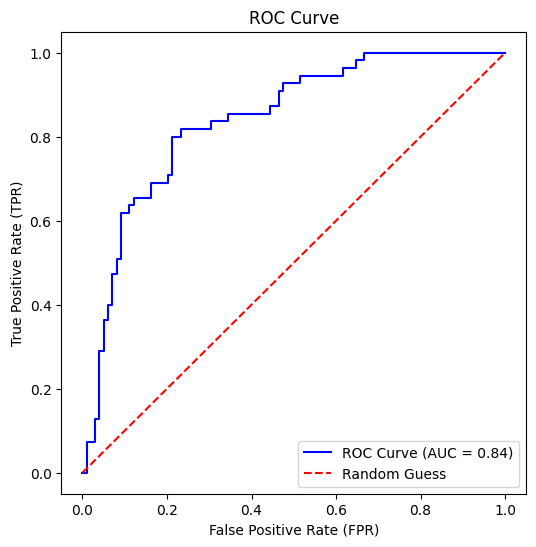

In [74]:
from sklearn.neural_network import MLPClassifier
MLP = MLPClassifier(hidden_layer_sizes=(16, 8),  # 2 hidden layers
                    activation='relu',
                    solver='adam',
                    learning_rate_init=0.01,
                    max_iter=500,
                    random_state=42)
MLP.fit(X_train,y_train)
y_pred = MLP.predict(X_test)
print('=== MLP Metrics ===')
Neural=accuracy_score(y_test,y_pred)
print('Accuracy => ',f"{accuracy_score(y_test,y_pred):.2f}")
print('precision => ',f"{precision_score(y_test,y_pred,average='weighted'):.2f}")
print('recall => ',f"{recall_score(y_test,y_pred,average='weighted'):.2f}")
print('F1-score: => ',f"{f1_score(y_test,y_pred,average='weighted'):.2f}")
print( '========================' )

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=['No Diabetes', 'Yes Diabetes'], yticklabels=['No Diabetes', 'Yes Diabetes']
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix –  MLP (Diabetes)")
plt.show()

print( '========================' )
# Get predicted probabilities for the positive class
y_prob = MLP.predict_proba(X_test)[:, 1]   # probability of class 1

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute AUC
auc = roc_auc_score(y_test, y_prob)

# Plot ROC Curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0,1], [0,1], color='red', linestyle='--', label='Random Guess')  # diagonal line
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend()
plt.show()

### 6) Random forest

=== RMC Metrics ===
Accuracy =>  0.78
precision =>  0.78
recall =>  0.78
F1-score: =>  0.78


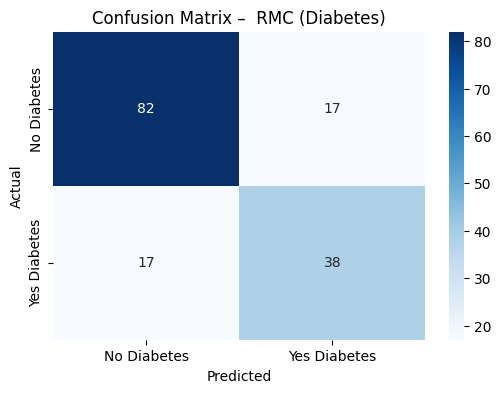

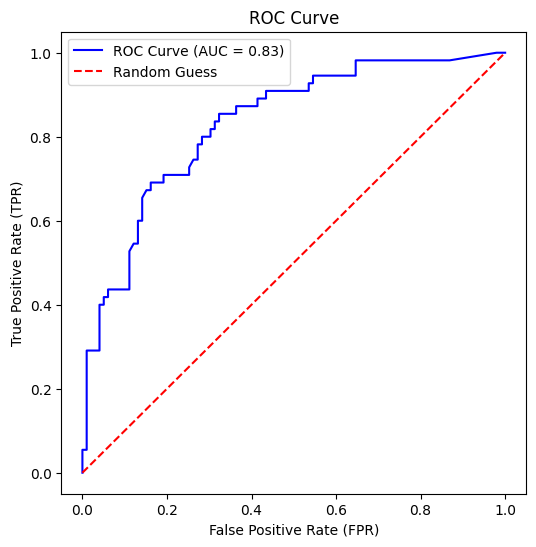

In [75]:
from sklearn.ensemble import RandomForestClassifier
RMC = RandomForestClassifier(n_estimators=20,random_state=42,max_depth=10)
RMC.fit(X_train,y_train)
y_pred = RMC.predict(X_test)
# RMC.score(X_train,y_train)
print('=== RMC Metrics ===')
RandomForest = accuracy_score(y_test,y_pred)
print('Accuracy => ',f"{accuracy_score(y_test,y_pred):.2f}")
print('precision => ',f"{precision_score(y_test,y_pred,average='weighted'):.2f}")
print('recall => ',f"{recall_score(y_test,y_pred,average='weighted'):.2f}")
print('F1-score: => ',f"{f1_score(y_test,y_pred,average='weighted'):.2f}")
print( '========================' )

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=['No Diabetes', 'Yes Diabetes'], yticklabels=['No Diabetes', 'Yes Diabetes']
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix –  RMC (Diabetes)")
plt.show()

print( '========================' )
# Get predicted probabilities for the positive class
y_prob = RMC.predict_proba(X_test)[:, 1]   # probability of class 1

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute AUC
auc = roc_auc_score(y_test, y_prob)

# Plot ROC Curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0,1], [0,1], color='red', linestyle='--', label='Random Guess')  # diagonal line
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend()
plt.show()

### 7) Feature Importance (Random Forest)

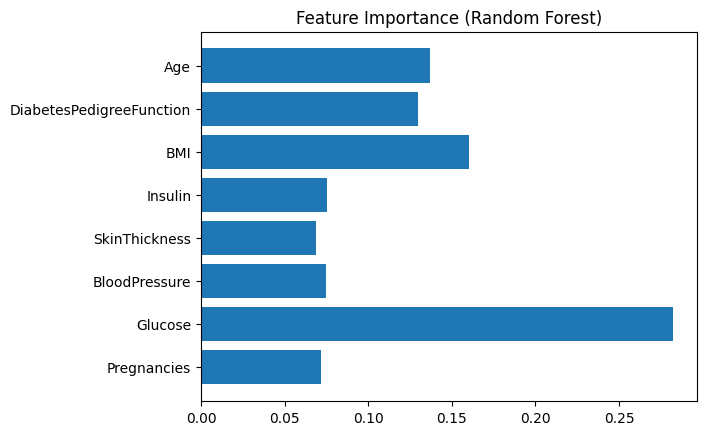

In [ ]:
# Feature Importance (Random Forest)
importances = RMC.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance (Random Forest)")
plt.show()


## Comparision 🆚⚖️

### 8) Models Accuracy Comparison

C:\Users\ASUS\AppData\Local\Temp\ipykernel_5880\799312638.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette="Blues_d")


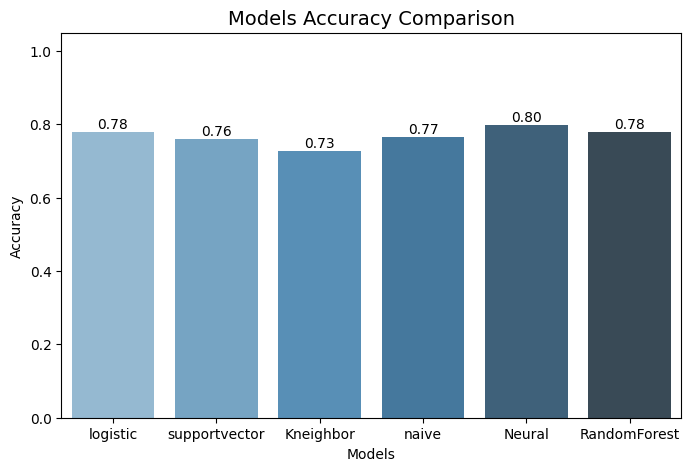

In [78]:
Models_accuacy = {'logistic':logistic,
                  'supportvector':supportvector,
                  'Kneighbor':Kneighbor,
                  'naive':naive,
                  'Neural':Neural,
                  'RandomForest':RandomForest}
import seaborn as sns
import matplotlib.pyplot as plt

# حول dict إلى lists
models = list(Models_accuacy.keys())
accuracies = list(Models_accuacy.values())

plt.figure(figsize=(8,5))
sns.barplot(x=models, y=accuracies, palette="Blues_d")

# # كتابة القيم فوق الأعمدة
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.01, f"{acc:.2f}", ha='center', fontsize=10)

plt.title("Models Accuracy Comparison", fontsize=14)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0,1.05)  # accuracy بين 0 و 1
plt.show()

